# ForestSim Dataset Analysis

This notebook is part of the thesis work on autonomous navigation for the Boston Dynamics Spot robot in forest environments, which combines semantic segmentation and traversability estimation.

Since ForestSim is a new dataset for this project, this notebook performs a first exploratory analysis of it before any model training takes place. It downloads and inspects the raw data, reports general statistics (number of samples, image resolution, class list), visually inspects RGB images and their semantic segmentation masks, and analyzes the distribution of the 24 semantic classes across the training and test splits. The goal is to build an informed understanding of the data the teacher network was trained on, and to surface properties (class imbalance, image characteristics, dataset origin) that will influence later modeling choices, such as the loss weighting strategy and the design of the sim-to-real bridge for the student model.

## Setup and Dataset Download

The custom modules used throughout the notebook are imported first: `download_dataset` handles retrieval of the raw data, `dataset_info` provides structural and statistical summaries, `dataset_visualization` renders RGB images, segmentation masks and overlays, and `dataset_distribution` computes and plots the per-class pixel distribution.

`download_dataset()` is then called to make sure the dataset is available locally. It checks for the presence of the images, the annotations, and the `segmentation_mapping.xlsx` file that defines the class-to-color mapping, downloading only the missing parts. In this run all three components were already present, so the download step was simply skipped.

In [1]:
from dataset.download_dataset import *
from dataset.dataset_info import *
from dataset.dataset_visualization import *
from dataset.dataset_distribution import *

In [1]:
download_dataset()

images already exists. Skipping.
annotations already exists. Skipping.
segmentation_mapping.xlsx already exists. Skipping.
Dataset download completed.


## Dataset Structure and Summary

Before working with the data, it is useful to inspect how it is organized on disk. `print_dataset_structure()` prints the full directory tree, which confirms the expected layout: an `images` folder with `train` and `test` subfolders containing the RGB frames, an `annotations` folder with the corresponding (unconverted) split annotations, and the `segmentation_mapping.xlsx` file at the root, which defines the class palette used in the masks.

In [3]:
print_dataset_structure()


Dataset structure:
[DIR] __MACOSX
    [DIR] images
        [FILE] ._.DS_Store
        [DIR] test
        [DIR] train
[DIR] annotations
    [DIR] __MACOSX
        [DIR] unconverted_split_annotations
    [DIR] unconverted_split_annotations
        [FILE] .DS_Store
        [DIR] test
        [DIR] train
[DIR] images
    [FILE] .DS_Store
    [DIR] test
        [FILE] .DS_Store
        [FILE] 100_MedievalVillage.png
        [FILE] 101_NordicAutoBiomeSpring.png
        ...
    [DIR] train
        [FILE] 100_Land.png
        [FILE] 100_LowPolySnow.png
        [FILE] 100_NordicAutoBiomeAutumn.png
        ...
[FILE] segmentation_mapping.xlsx


`dataset_summary()` then aggregates the key statistics of the dataset. The training set contains 1884 images and the test set 210, for a total of 2094 files (2093 valid images once corrupted/unreadable files are excluded). All images share the exact same resolution, 2048x1024 pixels, which means no resizing-related distortion needs to be accounted for when comparing samples, only the target resolution used for training the segmentation models.

The dataset defines 24 semantic classes, ranging from natural terrain classes relevant to off-road navigation (`grass`, `tree`, `rock`, `bush`, `water`, `mulch`, `rockbed`, `log`) to man-made and infrastructure classes (`pole`, `asphalt`, `concrete`, `fence`, `sign`, `bridge`, `building`, `table`), a few dynamic/object classes (`vehicle`, `bicycle`, `person`), and two catch-all classes, `void` and `generic ground`, likely used for pixels that do not fit any of the other categories or whose ground material is not further specified.

In [2]:
dataset_summary()

Forest Semantic Segmentation Dataset
Train files: 1884
Test files:  210
Total files: 2094

Number of images: 2093
Image width range: 2048 - 2048
Max image width: 2048
Min image width: 2048
Image height range: 1024 - 1024
Max image height: 1024
Min image height: 1024
Unique image sizes: 1
Size (2048, 1024): 2093 images


Dataset classes

 0 : grass
 1 : tree
 2 : pole
 3 : water
 4 : sky
 5 : vehicle
 6 : container generic object
 7 : asphalt
 8 : gravel
 9 : mulch
10 : rockbed
11 : log
12 : bicycle
13 : person
14 : fence
15 : bush
16 : sign
17 : rock
18 : bridge
19 : concrete
20 : table
21 : building
22 : void
23 : generic ground 


##  Visual Inspection

Numeric summaries only go so far when validating a new dataset, so this section visually inspects a set of RGB images together with their corresponding annotations, using several complementary views: a single sample, the color legend used to encode the classes, a semi-transparent overlay, and grids of multiple samples for a broader qualitative look.

### Random Sample: Image and Mask

`show_random_sample()` displays a randomly selected RGB image side by side with its ground-truth segmentation mask. In the sample drawn here (`35_NorthernWinter.png`), the mask correctly separates the sky (blue), the trees (green), and the ground (magenta, i.e. the `generic ground` class), with rocks highlighted in light blue. The RGB image itself has a distinctly synthetic, rendered look, and the file name follows a `<id>_<SceneName>` convention (here referencing a "Northern Winter" scene), which suggests that ForestSim is a synthetically generated dataset produced with a simulation or game engine rather than a collection of real-world photographs. This is an important observation for the thesis, since it directly motivates the sim-to-real bridging strategy considered for the student model.

Sample: 35_NorthernWinter.png


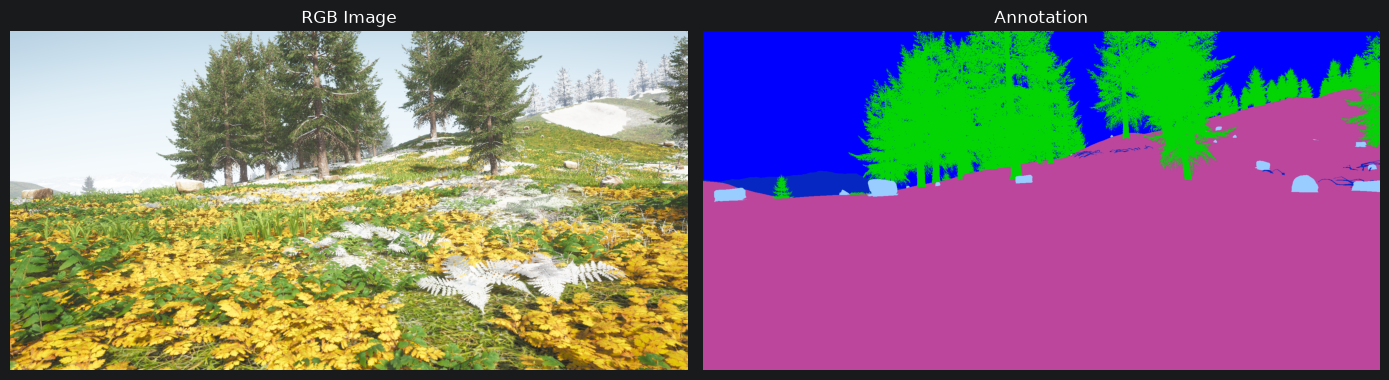

In [8]:
show_random_sample()

###  Class Color Legend

`show_class_legend()` renders the full color legend used to encode the 24 classes in the annotation masks, together with their RGB values. Having this legend available is essential to correctly interpret every other visualization in the notebook, and it will also be needed later to build the color-to-index conversion used when loading masks for training.

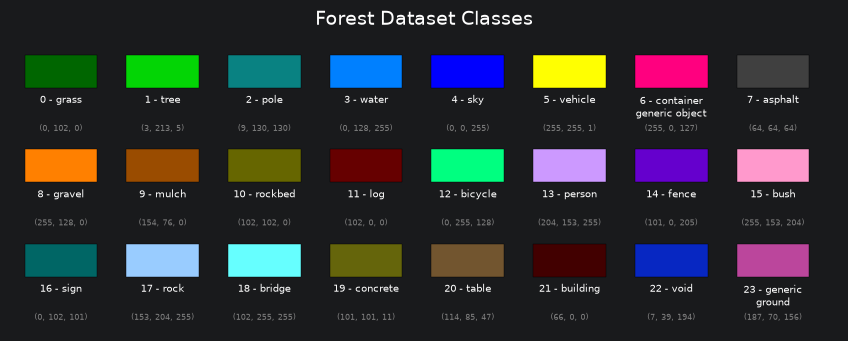

In [2]:
show_class_legend()

### Mask Overlay

`show_random_overlay()` blends a randomly chosen segmentation mask on top of its RGB image with transparency, which makes it easier to check that the annotation boundaries actually align with the visible objects in the scene. In the example produced here, a park-like path scene, the overlay shows a good alignment between the tree canopy, the paved path (asphalt), and the sky region, confirming that the annotations are spatially consistent with the underlying image.

Sample: 353_CityEnvironment.png


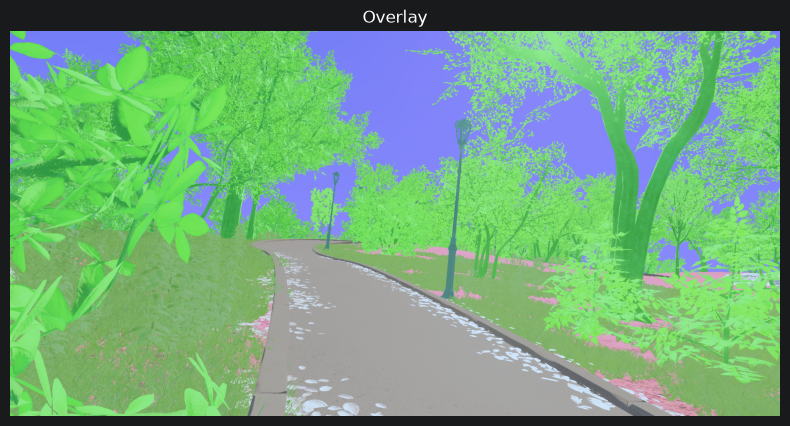

In [10]:
show_random_overlay()

###  Sample Comparison Grid

`compare_samples()` arranges nine image/mask pairs in a single grid, allowing several scenes to be compared at a glance. This view is particularly useful to get a sense of the diversity of environments included in ForestSim, in terms of biome (winter, autumn, temperate forest, etc.), lighting, and scene layout.

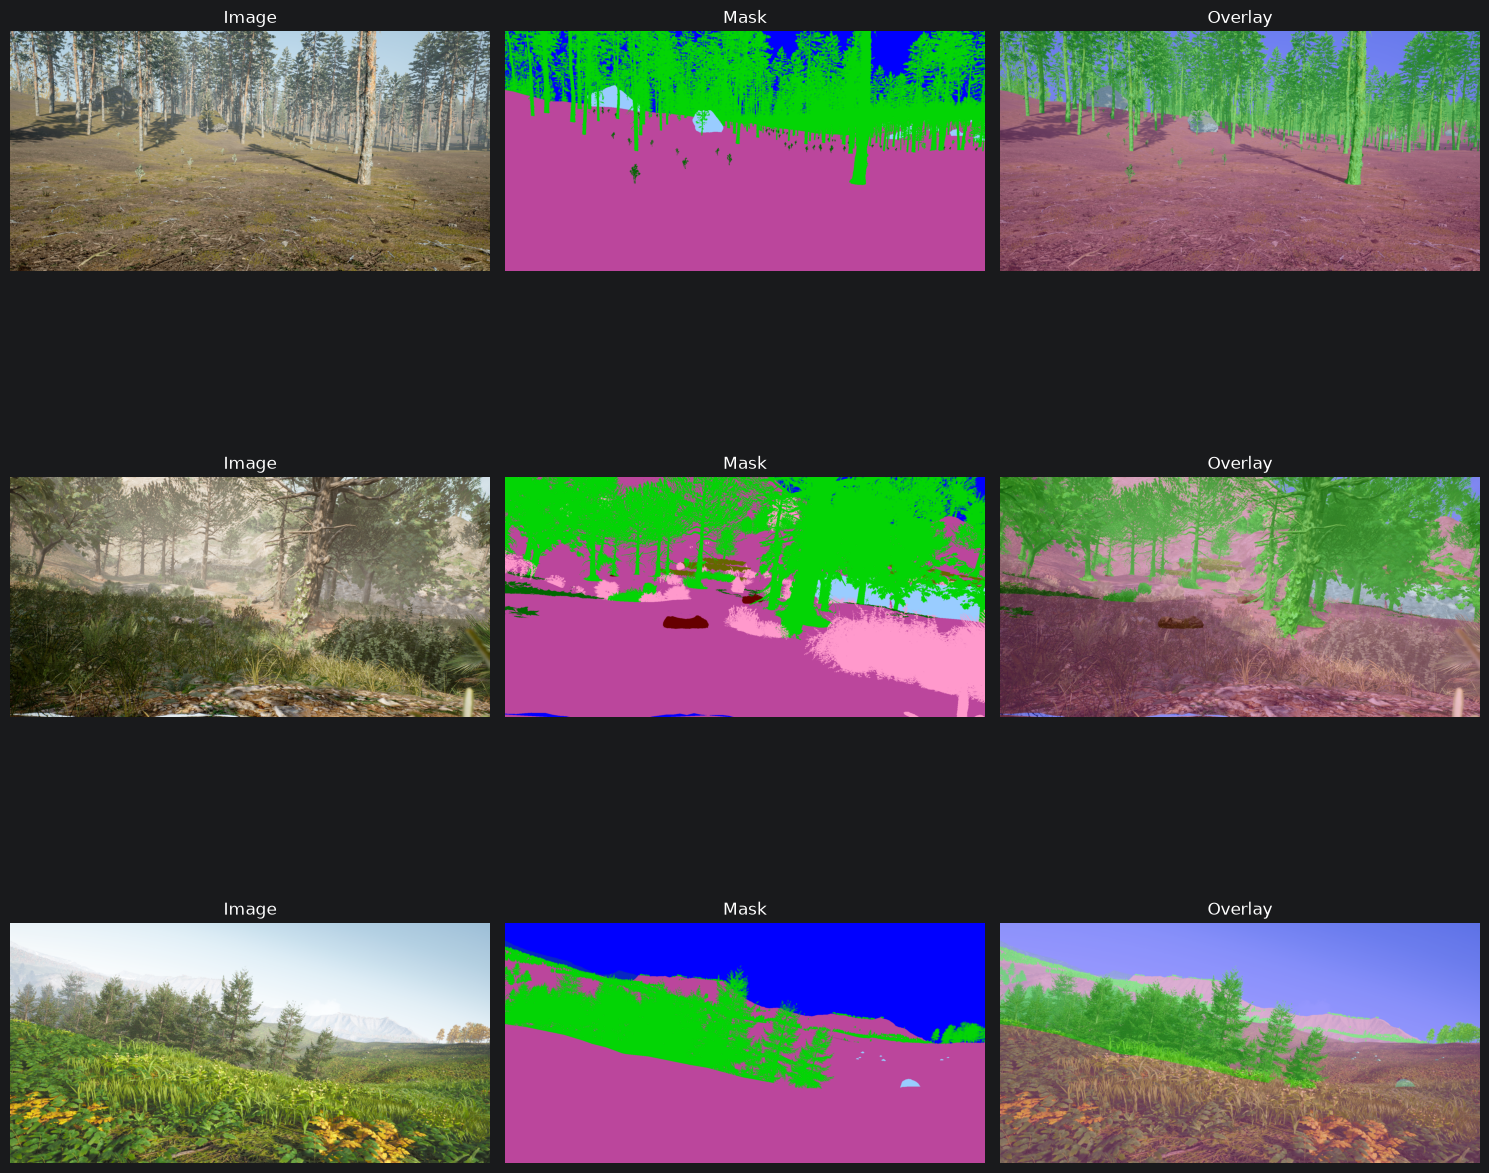

In [11]:
compare_samples()

### Random Samples Grid

`show_samples_grid(n=9)` shows a further set of nine randomly sampled scenes. Together with the previous grid, this gives a broader qualitative overview of the dataset and helps confirm that the variety observed is not limited to a handful of scenes, but spans a range of different synthetic forest and outdoor environments.

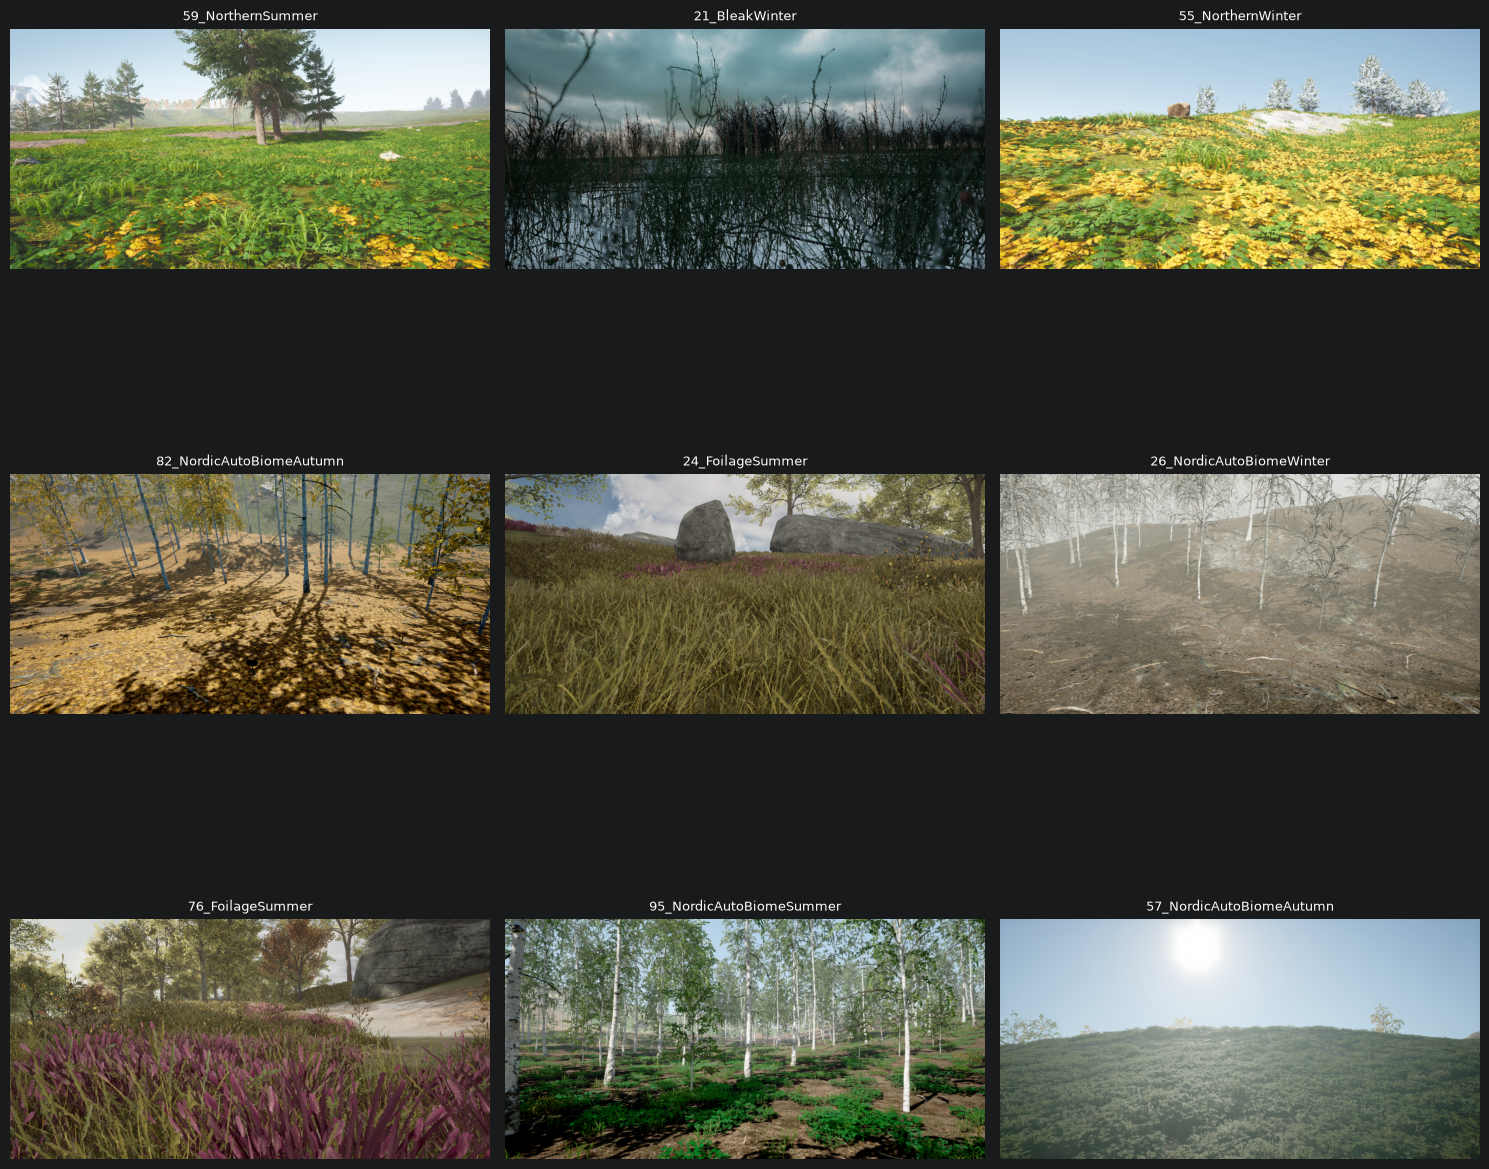

In [12]:
show_samples_grid(n=9)

## Class Distribution Analysis

After the qualitative inspection, this section quantifies how the 24 classes are distributed across the dataset, in terms of pixel percentage, separately for the training and the test split. This analysis is essential to anticipate class imbalance issues that will affect the training of any segmentation model on this data, including the loss function design for the student model that will be distilled from VIS-FORESTSIM.

### Training Set

`print_class_distribution()` and `plot_class_distribution()` report the per-class pixel percentage on the training split. The distribution is strongly imbalanced: four classes alone, `generic ground` (35.89%), `tree` (25.14%), `sky` (14.41%) and `grass` (9.87%), account for roughly 85% of all annotated pixels. At the opposite end, several classes relevant to obstacle detection are extremely rare, such as `pole` and `gravel` (0.15%), `table` (0.03%), and `vehicle` (0.00%, essentially absent from the training set). This kind of long-tailed distribution is typical of outdoor segmentation datasets, but it is worth keeping in mind for the thesis: a plain cross-entropy loss would be dominated by the majority classes, so techniques such as class weighting, focal loss, or oversampling of rare-class regions are likely to be needed when training or fine-tuning on this data.

In [3]:
print_class_distribution()


Class distribution
------------------------------------------------------------
generic ground                   35.89%
tree                             25.14%
sky                              14.41%
grass                             9.87%
rock                              3.67%
bush                              2.77%
water                             2.67%
asphalt                           1.35%
concrete                          0.71%
fence                             0.64%
void                              0.48%
building                          0.48%
mulch                             0.43%
bridge                            0.38%
container generic object          0.37%
log                               0.24%
rockbed                           0.17%
gravel                            0.15%
pole                              0.15%
table                             0.03%
Unknown                           0.01%
vehicle                           0.00%


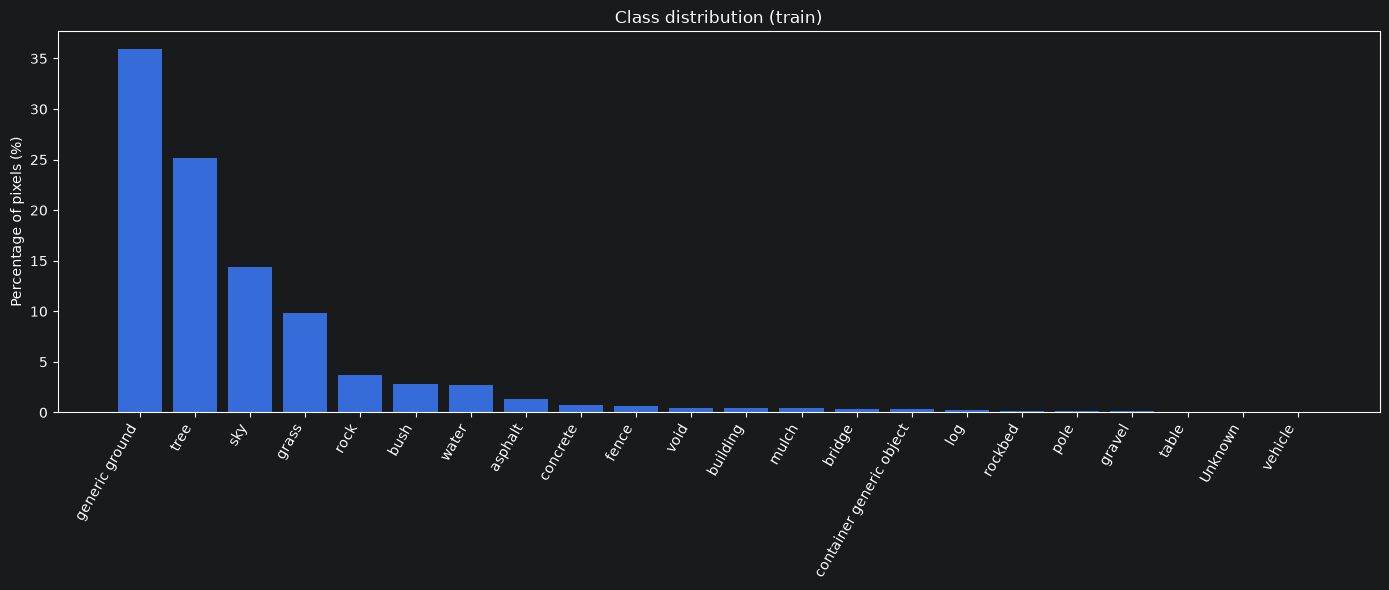

In [7]:
plot_class_distribution()

###  Test Set

The same analysis is repeated on the test split with `print_class_distribution("test")` and `plot_class_distribution("test")`. The resulting distribution closely mirrors the one observed on the training set, with `generic ground` (37.50%), `tree` (25.56%), `sky` (13.58%) and `grass` (9.31%) again dominating, and the same rare classes (`vehicle`, `table`, `pole`) barely represented. The close agreement between the two splits is a positive sign: it indicates that the train/test split is well stratified and that models trained on this data should not encounter a significant distribution shift at test time purely due to class frequency.

In [13]:
print_class_distribution("test")


Class distribution
------------------------------------------------------------
generic ground                   37.50%
tree                             25.56%
sky                              13.58%
grass                             9.31%
rock                              3.75%
bush                              2.73%
water                             2.22%
asphalt                           1.07%
building                          0.98%
fence                             0.80%
void                              0.68%
mulch                             0.41%
log                               0.41%
container generic object          0.31%
bridge                            0.27%
gravel                            0.20%
rockbed                           0.11%
pole                              0.07%
concrete                          0.02%
Unknown                           0.01%
table                             0.00%
vehicle                           0.00%


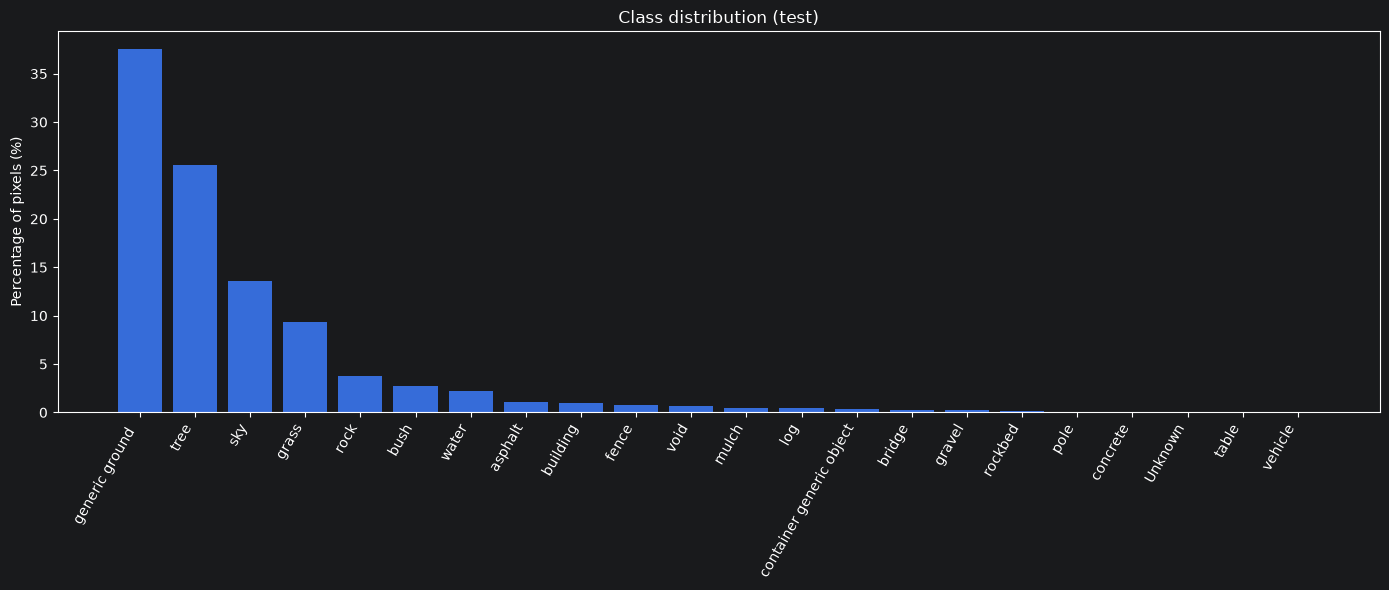

In [14]:
plot_class_distribution("test")

## Summary and Next Steps

This exploratory analysis confirms that ForestSim is a synthetically generated, high-resolution (2048x1024) semantic segmentation dataset covering 24 classes, with 1884 training images and 210 test images. The visual inspection showed annotations that are well aligned with the underlying RGB content across a variety of outdoor scenes, while the distribution analysis highlighted a strong, but consistent, class imbalance dominated by `generic ground`, `tree`, `sky` and `grass`, and revealed several classes that are effectively rare in the dataset (`vehicle`, `table`, `pole`, `gravel`).

These findings will directly inform the next steps of the thesis: the class imbalance suggests that a weighted loss or resampling strategy should be considered when training or evaluating the model, and the synthetic nature of the images reinforces the relevance of using semantic segmentation as a sim-to-real bridge.